In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("data/bird_observation_cleaned.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (3921, 32)

Columns:
['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer', 'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed', 'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode', 'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt', 'Habitat', 'TaxonCode', 'Previously_Obs']

First 5 Rows:


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN


In [2]:
# ==========================================
# STEP 2: DATA TYPES & MISSING VALUES
# ==========================================

print("========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing_Count",
    ascending=False
)

display(missing_table)

========== DATA TYPES ==========
Admin_Unit_Code                    str
Sub_Unit_Code                  float64
Site_Name                          str
Plot_Name                          str
Location_Type                      str
Year                             int64
Date                               str
Start_Time                         str
End_Time                           str
Observer                           str
Visit                            int64
Interval_Length                    str
ID_Method                          str
Distance                           str
Flyover_Observed                  bool
Sex                                str
Common_Name                        str
Scientific_Name                    str
AcceptedTSN                    float64
NPSTaxonCode                   float64
AOU_Code                           str
PIF_Watchlist_Status              bool
Regional_Stewardship_Status       bool
Temperature                    float64
Humidity                       

,Missing_Count,Missing_Percentage
Sub_Unit_Code,3921,100.000000
NPSTaxonCode,3588,91.507269
Site_Name,3588,91.507269
Distance,335,8.543739
TaxonCode,334,8.518235
Previously_Obs,333,8.492731
Sex,221,5.636317
AcceptedTSN,21,0.535578
ID_Method,1,0.025504
Sky,0,0.000000


In [3]:
# ==========================================
# UNIVARIATE ANALYSIS
# NUMERICAL VARIABLES
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

print("\nNumber of Numerical Columns:", len(numerical_cols))

Numerical Columns:
['Sub_Unit_Code', 'Year', 'Visit', 'AcceptedTSN', 'NPSTaxonCode', 'Temperature', 'Humidity', 'TaxonCode']

Number of Numerical Columns: 8


In [4]:
# ==========================================
# NUMERICAL COLUMNS - STATISTICAL SUMMARY
# ==========================================

print("========== NUMERICAL DATA SUMMARY ==========")

numerical_summary = df[numerical_cols].describe().T

print(numerical_summary)

========== NUMERICAL DATA SUMMARY ==========
                count           mean           std            min       25%  \
Sub_Unit_Code     0.0            NaN           NaN            NaN       NaN   
Year           3921.0    2018.000000      0.000000    2018.000000    2018.0   
Visit          3921.0       1.904616      0.804694       1.000000       1.0   
AcceptedTSN    3900.0  197964.171026  88745.469586  174999.000000  178581.0   
NPSTaxonCode    333.0  112177.567568  88740.680703   82737.000000   85791.0   
Temperature    3921.0      23.981051      4.936211      12.900000      21.0   
Humidity       3921.0      68.737822     13.854467      32.900002      59.0   
TaxonCode      3587.0  102455.164483  84034.740715   76625.000000   84790.0   

                         50%            75%            max  
Sub_Unit_Code            NaN            NaN            NaN  
Year             2018.000000    2018.000000    2018.000000  
Visit               2.000000       3.000000       3.000000  

In [5]:
# ==========================================
# CATEGORICAL COLUMNS
# ==========================================

categorical_cols = df.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("========== CATEGORICAL COLUMNS ==========")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

========== CATEGORICAL COLUMNS ==========
['Admin_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Date', 'Start_Time', 'End_Time', 'Observer', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed', 'Sex', 'Common_Name', 'Scientific_Name', 'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt', 'Habitat', 'Previously_Obs']

Number of categorical columns: 24


C:\Users\HP\AppData\Local\Temp\ipykernel_14516\293676584.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [6]:
# ==========================================
# CATEGORICAL DATA SUMMARY
# ==========================================

print("========== CATEGORICAL DATA SUMMARY ==========")

categorical_summary = pd.DataFrame({
    "Unique_Count": df[categorical_cols].nunique(dropna=True),
    "Missing_Count": df[categorical_cols].isnull().sum()
})

categorical_summary = categorical_summary.sort_values(
    by="Unique_Count",
    ascending=False
)

print(categorical_summary)

========== CATEGORICAL DATA SUMMARY ==========
                             Unique_Count  Missing_Count
Start_Time                            195              0
End_Time                              195              0
Plot_Name                              99              0
Scientific_Name                        81              0
Common_Name                            80              0
AOU_Code                               80              0
Date                                    9              0
Disturbance                             4              0
Interval_Length                         4              0
Wind                                    4              0
Sky                                     4              0
Sex                                     3            221
Observer                                3              0
ID_Method                               3              1
PIF_Watchlist_Status                    2              0
Regional_Stewardship_Status             2

In [7]:
# ==========================================
# TOP BIRD SPECIES
# ==========================================

print("========== TOP 15 BIRD SPECIES ==========")

species_counts = (
    df["Common_Name"]
    .value_counts()
    .head(15)
)

print(species_counts)

========== TOP 15 BIRD SPECIES ==========
Common_Name
Field Sparrow              345
Northern Cardinal          321
Indigo Bunting             228
Chipping Sparrow           225
Mourning Dove              185
Grasshopper Sparrow        185
American Goldfinch         178
Barn Swallow               159
Carolina Wren              156
Eastern Towhee             115
American Crow              115
Eastern Bluebird           110
Brown-headed Cowbird       100
Eastern Tufted Titmouse     90
Northern Mockingbird        86
Name: count, dtype: int64


### Analysis Type
Univariate Analysis

## Chart 1: Which Bird Species Have the Highest Number of Observations?

## Objective
To identify the most frequently observed bird species in the combined bird observation dataset and determine which species have the highest observation counts.

## Business Purpose
Understanding the frequency of bird observations helps identify commonly observed species and provides a baseline for monitoring bird populations and planning future ecological surveys.

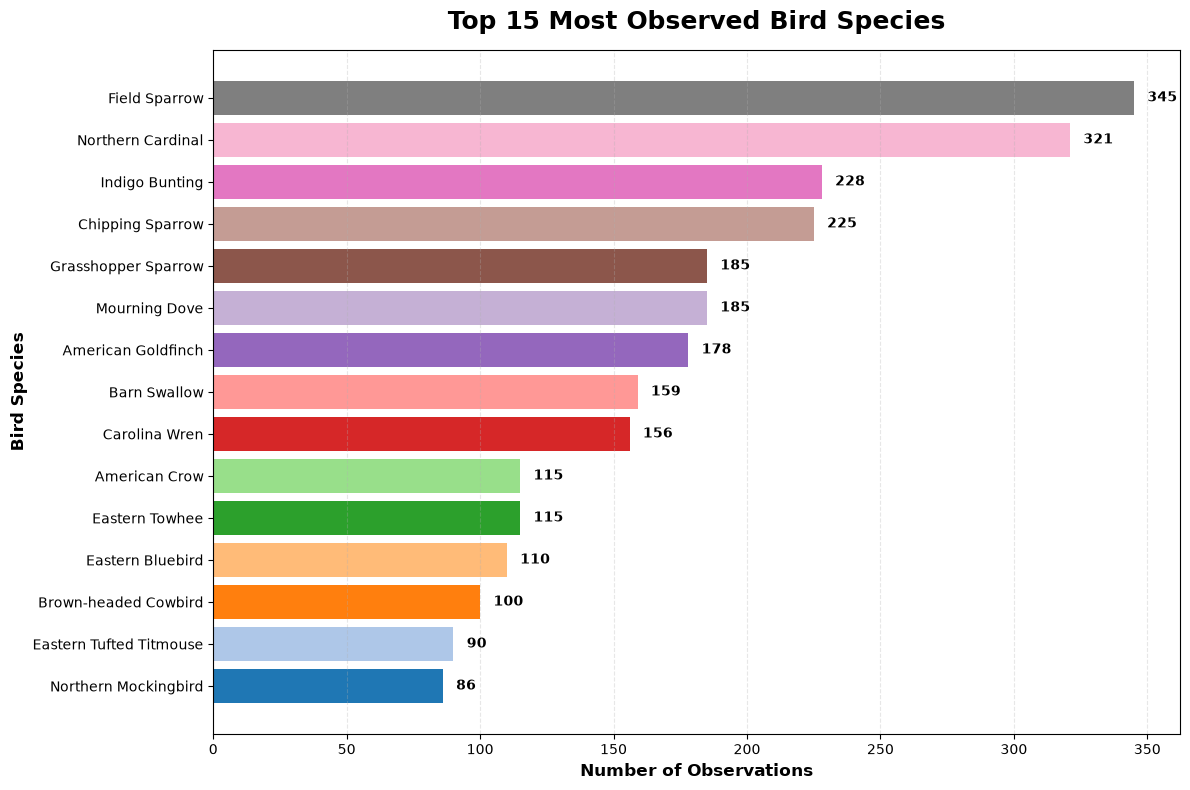

In [8]:
# ==========================================
# CHART 1: TOP 15 MOST OBSERVED BIRD SPECIES
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Count observations for each bird species
species_counts = (
    df["Common_Name"]
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

# Create figure
plt.figure(figsize=(12, 8))

# Create multi-color horizontal bar chart
bars = plt.barh(
    species_counts.index,
    species_counts.values,
    color=plt.cm.tab20.colors[:15]
)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Title
plt.title(
    "Top 15 Most Observed Bird Species",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Number of Observations",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Bird Species",
    fontsize=12,
    fontweight="bold"
)

# Grid for readability
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

### Business Insight

Field Sparrow has the highest number of observations with 345 records, followed by Northern Cardinal with 321 observations. Indigo Bunting and Chipping Sparrow also show relatively high observation counts with 228 and 225 records respectively.

In comparison, Northern Mockingbird has the lowest observation count among the top 15 species, with 86 observations. Overall, the chart indicates that observation activity is concentrated among a smaller group of commonly recorded bird species.

### Business Recommendation

Bird monitoring teams should continue regular monitoring of highly observed species such as Field Sparrow and Northern Cardinal to track population patterns over time. At the same time, species with comparatively lower observation frequencies should receive additional attention to determine whether their lower counts are related to habitat conditions, seasonal patterns, or limited observation coverage.

## Chart 2: How Are Bird Observations Distributed Across Habitats?

- **Objective:** Compare bird observation counts between Forest and Grassland habitats.
- **Business Purpose:** Understand which habitat has greater observation coverage.

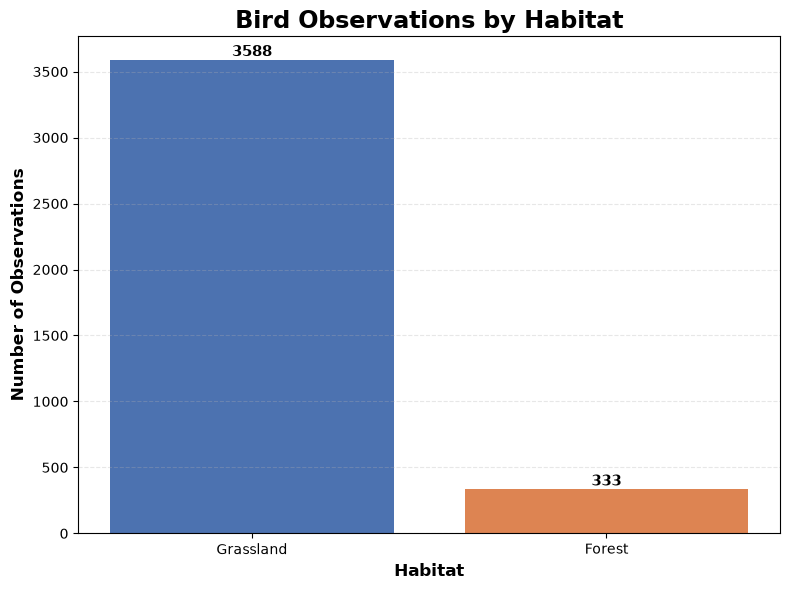

In [9]:
# ==========================================
# CHART 2: BIRD OBSERVATIONS BY HABITAT
# ==========================================

import matplotlib.pyplot as plt

habitat_counts = df["Habitat"].value_counts()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    habitat_counts.index,
    habitat_counts.values,
    color=["#4C72B0", "#DD8452"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Bird Observations by Habitat",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Habitat", fontsize=12, fontweight="bold")
plt.ylabel("Number of Observations", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Business Insight
Grassland recorded **3,588 bird observations**, compared with only **333 observations in Forest**. This shows that the dataset has a much higher representation of bird observations from grassland habitat.

### 🎯 Business Recommendation
Maintain strong monitoring activities in **Grassland**, while increasing observation efforts in **Forest** to achieve better habitat representation and identify under-observed bird species.

## 📊 Chart 3: Bird Observations Across Survey Visits

### Question
How does the number of bird observations vary across different survey visits?
### Objective
To compare bird observation activity across different survey visits and identify the visit with the highest observation count.

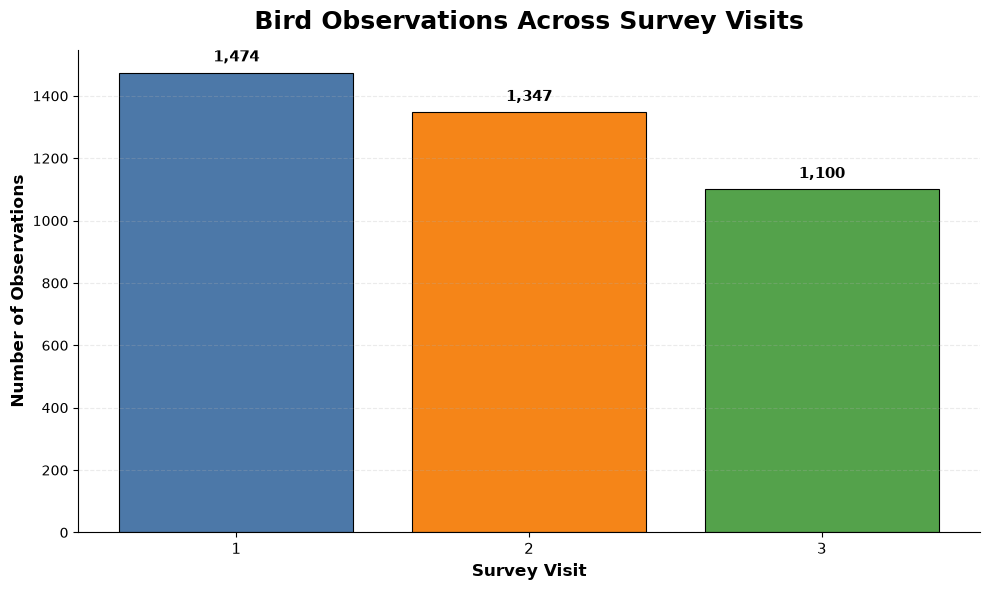

In [11]:
# ==========================================
# CHART 3: BIRD OBSERVATIONS BY VISIT
# ==========================================

import matplotlib.pyplot as plt

visit_counts = df["Visit"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B"]

bars = plt.bar(
    visit_counts.index.astype(str),
    visit_counts.values,
    color=colors[:len(visit_counts)],
    edgecolor="black",
    linewidth=0.8
)

plt.title(
    "Bird Observations Across Survey Visits",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Survey Visit",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Observations",
    fontsize=12,
    fontweight="bold"
)

# Add value labels
for bar, value in zip(bars, visit_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Add light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- **Visit 1** recorded the highest number of observations with **1,474**.
- **Visit 2** recorded **1,347** observations.
- **Visit 3** recorded the lowest with **1,100** observations.
- Observation activity shows a gradual decline across the three visits.

### 💡 Business Insight

- **Visit 1** recorded the highest number of observations with **1,474**.
- **Visit 2** recorded **1,347** observations.
- **Visit 3** recorded the lowest with **1,100** observations.
- Observation activity shows a gradual decline across the three visits.

## 📊 Chart 4: Bird Observations by Sky Condition

### Question
How does the sky condition vary across bird observation records?
### Objective
To analyze the distribution of bird observations under different sky conditions.

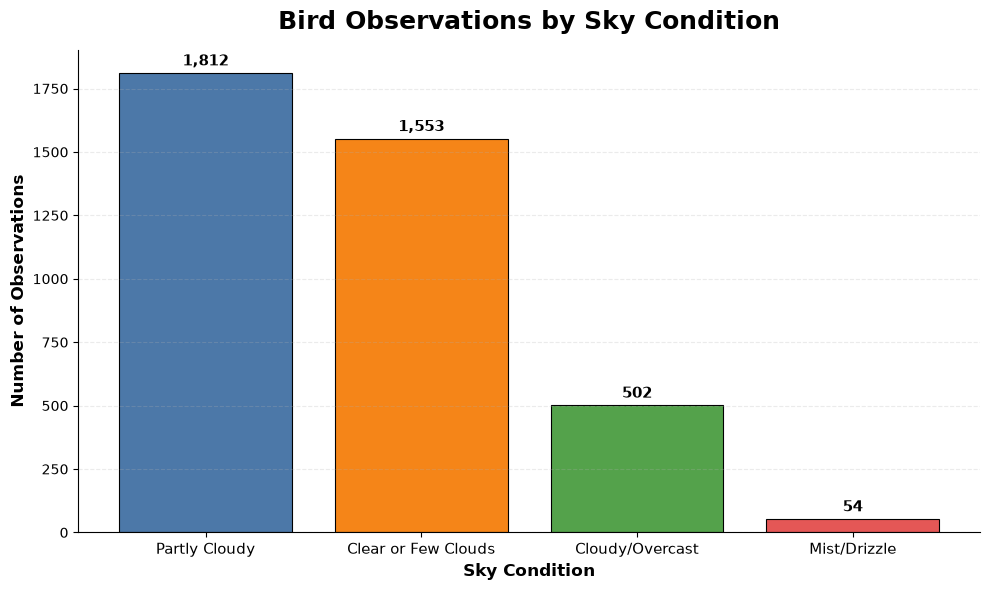

In [12]:
# ==========================================
# CHART 4: BIRD OBSERVATIONS BY SKY CONDITION
# ==========================================

import matplotlib.pyplot as plt

sky_counts = df["Sky"].value_counts()

plt.figure(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

bars = plt.bar(
    sky_counts.index,
    sky_counts.values,
    color=colors[:len(sky_counts)],
    edgecolor="black",
    linewidth=0.8
)

plt.title(
    "Bird Observations by Sky Condition",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Sky Condition",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Observations",
    fontsize=12,
    fontweight="bold"
)

# Value labels
for bar, value in zip(bars, sky_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- **Partly Cloudy** conditions recorded the highest observations with **1,812**.
- **Clear or Few Clouds** recorded **1,553** observations.
- **Cloudy/Overcast** conditions recorded **502** observations.
- **Mist/Drizzle** had the lowest observations with only **54**.

### 🎯 Business Recommendation

- Focus monitoring analysis on **Partly Cloudy** and **Clear or Few Clouds** conditions because most observations occurred under these conditions.
- Further investigate whether bird activity actually changes with sky conditions rather than assuming the difference is caused by weather.
- Include sky condition as an environmental factor in future comparative and multivariate analysis.

## 📊 Chart 5: Which Bird Species Have the Highest Observation Counts Across Visits?

### 🎯 Objective
To compare observation counts of the most frequently recorded bird species across different visits and identify species that show consistently higher observation frequencies.

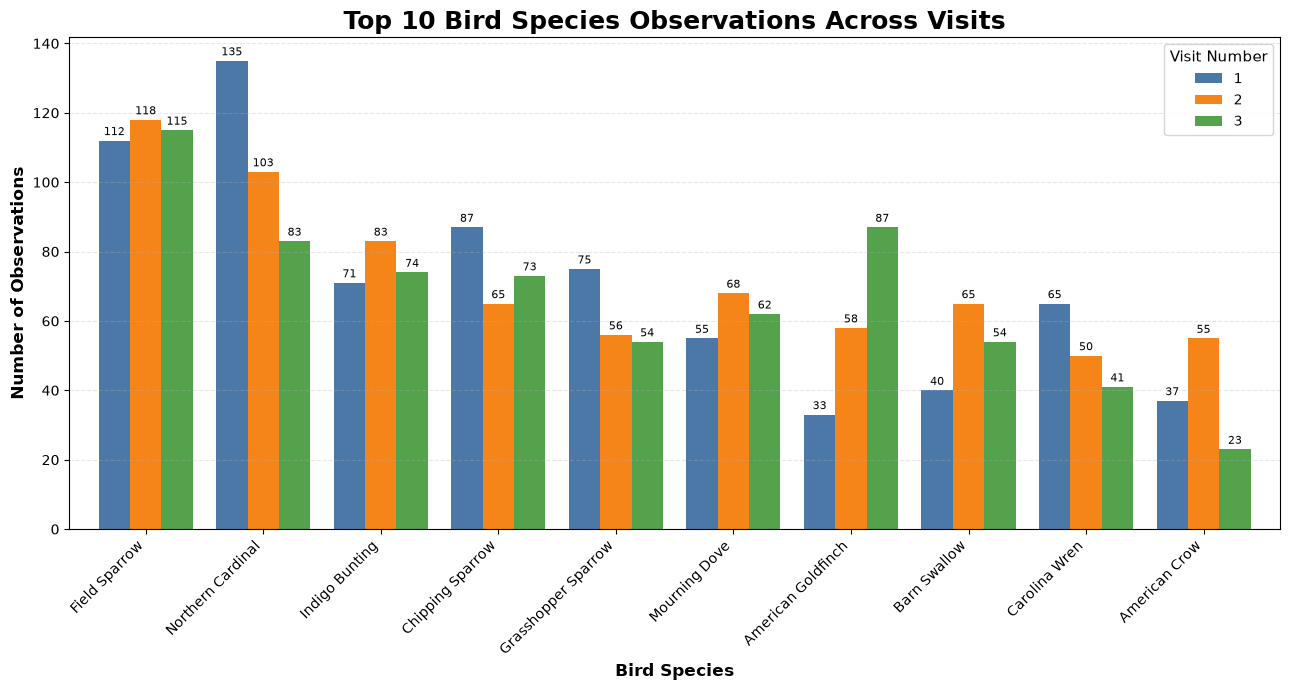

In [13]:
# ==========================================
# CHART 5: BIRD SPECIES OBSERVATIONS BY VISIT
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Create cross-tabulation
species_visit = pd.crosstab(
    df["Common_Name"],
    df["Visit"]
)

# Select Top 10 species based on total observations
top_species = species_visit.sum(axis=1).nlargest(10).index
species_visit_top = species_visit.loc[top_species]

# Plot
ax = species_visit_top.plot(
    kind="bar",
    figsize=(13, 7),
    width=0.8,
    color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.title(
    "Top 10 Bird Species Observations Across Visits",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Bird Species", fontsize=12, fontweight="bold")
plt.ylabel("Number of Observations", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Visit Number",
    title_fontsize=11,
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

## 💡 Business Insight

- **Field Sparrow** shows consistently high observations across all three visits, with **112, 118, and 115** observations respectively.
- **Northern Cardinal** recorded the highest single-visit observation with **135 observations in Visit 1**, but declined to **83 in Visit 3**.
- **American Goldfinch** shows a strong increase across visits, rising from **33 in Visit 1 to 87 in Visit 3**.
- **American Crow** has relatively low observations, with only **23 observations in Visit 3**.
- Overall, observation patterns vary by species, indicating that some species remain consistently present while others show noticeable changes across visits.

## 🎯 Business Recommendation

- Prioritize monitoring of consistently observed species such as **Field Sparrow** to establish reliable population trends.
- Investigate the reasons behind the decline of species such as **Northern Cardinal** across visits.
- Conduct further observations during periods where **American Goldfinch** activity is increasing.
- Give additional monitoring attention to species with consistently lower observations, such as **American Crow**, to determine whether the pattern reflects true abundance or observation conditions.

## BIVARIATE ANALYSIS

## 📊 Bivariate Chart 1: How Does Bird Observation Frequency Vary Across Different Habitats?

### 🎯 Objective
To compare bird observation frequencies across different habitats and identify which bird species are more frequently observed in each habitat.

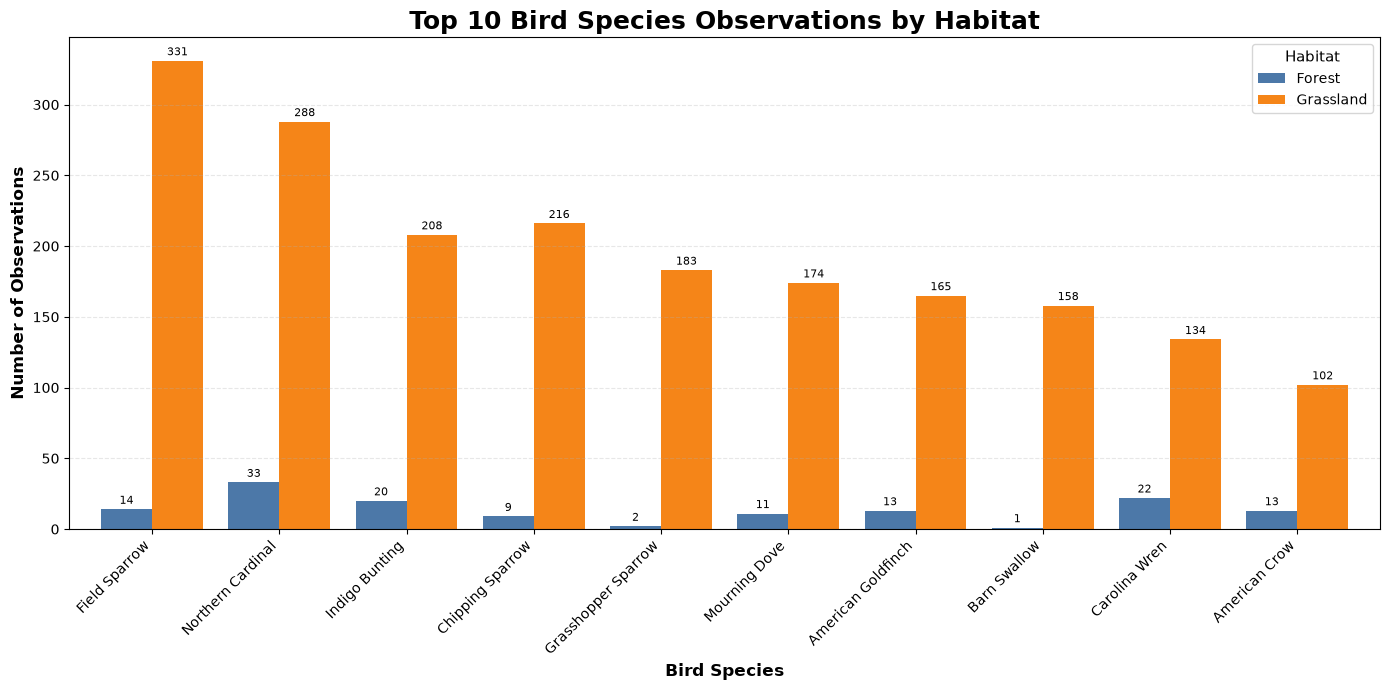

In [15]:
# ==========================================
# BIVARIATE CHART 1
# BIRD SPECIES × HABITAT
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Create cross-tabulation
habitat_species = pd.crosstab(
    df["Common_Name"],
    df["Habitat"]
)

# Select Top 10 bird species based on total observations
top_species = habitat_species.sum(axis=1).nlargest(10).index
habitat_species_top = habitat_species.loc[top_species]

# Plot
ax = habitat_species_top.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8,
    color=["#4C78A8", "#F58518"]
)

plt.title(
    "Top 10 Bird Species Observations by Habitat",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Bird Species",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Observations",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Habitat",
    fontsize=10,
    title_fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

## 💡 Business Insight

- **Grassland** has substantially higher observations than Forest across all top 10 bird species.
- **Field Sparrow** has the highest Grassland observations with **331**, compared with only **14** in Forest.
- **Northern Cardinal** is the second-highest in Grassland with **288 observations**, while Forest has only **33**.
- **Grasshopper Sparrow** shows the strongest Grassland preference, with **183 observations** versus only **2** in Forest.
- The large difference between habitats suggests that the observed bird species are predominantly associated with **Grassland habitat** in this dataset.
## 🎯 Business Recommendation

- Prioritize **Grassland areas** for regular bird population monitoring because they contain the majority of recorded observations.
- Conduct targeted conservation and habitat-management activities for species showing strong Grassland association.
- Investigate the very low Forest observations to determine whether they reflect genuine habitat preference or limited sampling coverage.
- Increase Forest monitoring to obtain a more balanced understanding of bird distribution across habitats.

## 📊 Bivariate Chart 2: How Do Bird Observations Vary by Habitat Across Different Visits?

### 🎯 Objective
To compare bird observation counts across different habitats and visits, and identify whether observation patterns change between visits.

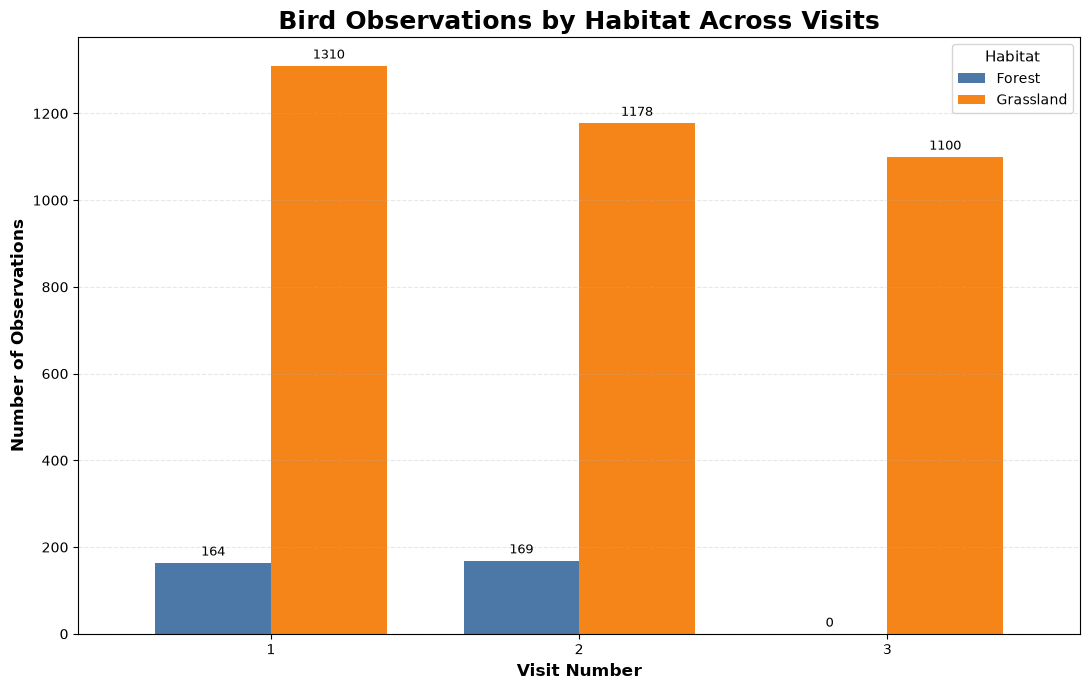

In [16]:
# ==========================================
# BIVARIATE CHART 2
# HABITAT × VISIT
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Create cross-tabulation
visit_habitat = pd.crosstab(
    df["Visit"],
    df["Habitat"]
)

# Plot
ax = visit_habitat.plot(
    kind="bar",
    figsize=(11, 7),
    width=0.75,
    color=["#4C78A8", "#F58518"]
)

plt.title(
    "Bird Observations by Habitat Across Visits",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Visit Number",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Observations",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Habitat",
    fontsize=10,
    title_fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        fontsize=9,
        padding=3
    )

plt.tight_layout()
plt.show()

## 💡 Business Insight

- **Grassland** observations are consistently much higher than Forest observations across all three visits.
- Grassland observations decreased from **1,310 in Visit 1** to **1,178 in Visit 2** and **1,100 in Visit 3**.
- Forest observations were relatively low, with **164 in Visit 1** and **169 in Visit 2**, while **Visit 3 recorded 0 Forest observations**.
- The overall pattern indicates that the dataset has a strong concentration of observations in **Grassland habitat**.

## 🎯 Business Recommendation

- Continue regular monitoring of **Grassland habitats**, as they account for the majority of recorded observations.
- Investigate why Grassland observations gradually declined across the three visits.
- Review the **0 Forest observations in Visit 3** to determine whether this resulted from sampling coverage or data collection conditions.
- Ensure Forest areas are included consistently in future visits to improve habitat-level comparison and monitoring reliability.

## 📊 Chart 3: How Does Temperature Distribution Vary Across Habitats?

### 🎯 Objective
To compare the distribution and variation of recorded temperatures across different habitats and identify whether environmental temperature conditions differ between Forest and Grassland observations.

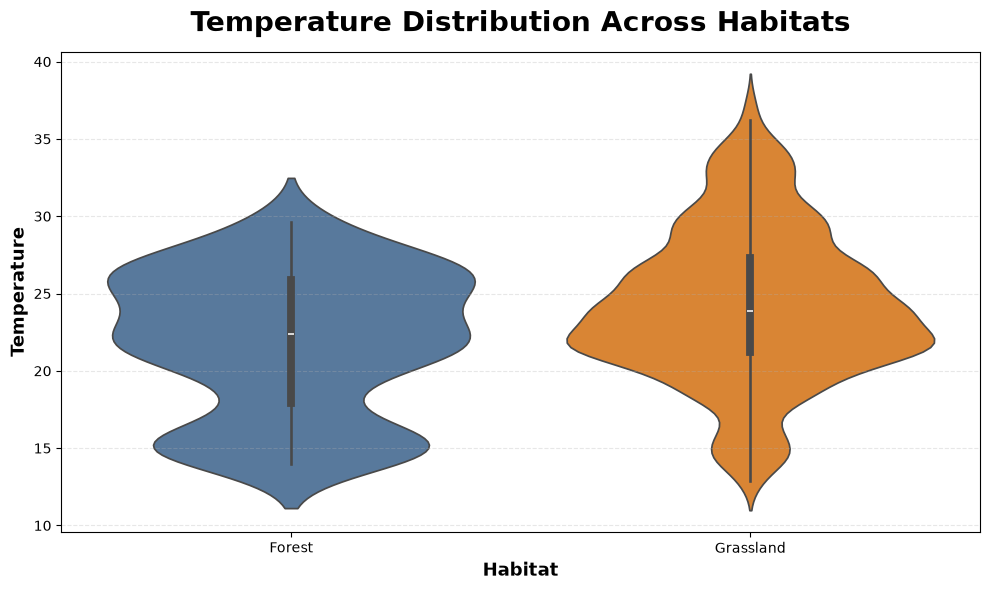

In [17]:
# ==========================================
# CHART 3: TEMPERATURE DISTRIBUTION BY HABITAT
# BIVARIATE ANALYSIS - VIOLIN PLOT
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Habitat",
    y="Temperature",
    hue="Habitat",
    palette=["#4C78A8", "#F58518"],
    inner="box",
    legend=False
)

plt.title(
    "Temperature Distribution Across Habitats",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Habitat", fontsize=13, fontweight="bold")
plt.ylabel("Temperature", fontsize=13, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 💡 Business Insight

- Grassland observations show a wider temperature range, approximately **12°C–39°C**.
- Forest observations are more concentrated, approximately **14°C–30°C**.
- Grassland has greater temperature variability, indicating more diverse environmental conditions.
- Forest temperatures appear relatively stable around the mid-20°C range.

### 🎯 Business Recommendation

- Plan bird monitoring activities across different temperature conditions, especially in Grassland.
- Use temperature variation as an environmental factor when analysing bird presence and observation patterns.
- Conduct observations across different temperature ranges to improve the reliability of ecological insights.

## 📊 Chart 4: How Do Bird Observations Vary by Habitat and Sky Condition?

### 🎯 Objective
To analyse the relationship between habitat type and sky condition and identify the combinations associated with the highest number of bird observations.

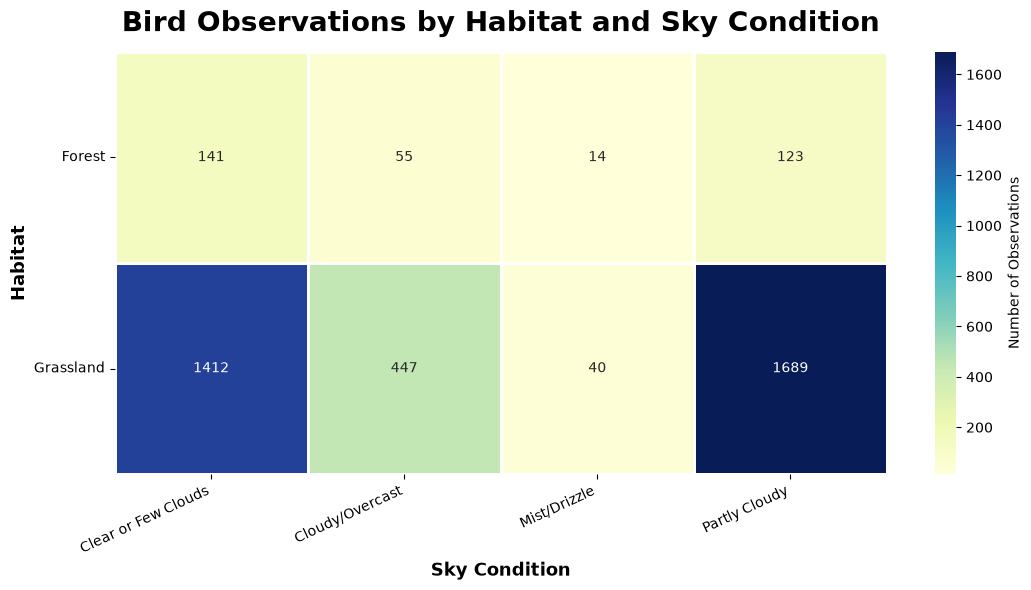

In [18]:
# ==========================================
# BIVARIATE CHART 4: HABITAT × SKY CONDITION
# HEATMAP
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create cross-tabulation
habitat_sky = pd.crosstab(
    df["Habitat"],
    df["Sky"]
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    habitat_sky,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Number of Observations"}
)

plt.title(
    "Bird Observations by Habitat and Sky Condition",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sky Condition", fontsize=13, fontweight="bold")
plt.ylabel("Habitat", fontsize=13, fontweight="bold")

plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Grassland has the highest observations under **Partly Cloudy (1,689)** and **Clear/Few Clouds (1,412)** conditions.
- Forest observations are much lower across all sky conditions.
- **Mist/Drizzle** has the lowest observations in both habitats.
- Overall, bird observations are strongly concentrated in Grassland under favourable sky conditions.

### 🎯 Business Recommendation

- Prioritize Grassland monitoring during **Partly Cloudy and Clear/Few Clouds** conditions.
- Maintain some observations under Cloudy/Overcast and Mist/Drizzle conditions to avoid weather-related sampling bias.
- Use Habitat and Sky Condition together when planning future bird-monitoring schedules.

## 📊 Chart 5: How Does Bird Observation Frequency Change with Temperature?

### 🎯 Objective
To analyse the relationship between temperature and bird observation frequency and identify temperature ranges associated with higher bird observations.

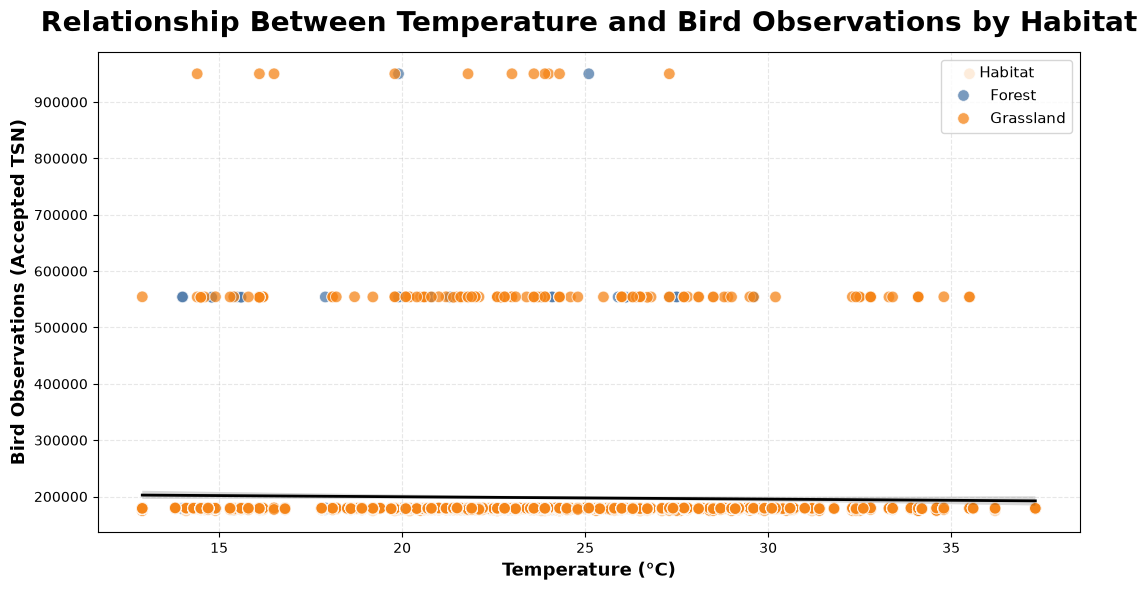

In [21]:
# ==========================================
# CHART 13: TEMPERATURE vs BIRD OBSERVATIONS
# COLORED SCATTER PLOT
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="AcceptedTSN",
    hue="Habitat",
    palette=["#4C78A8", "#F58518"],
    s=70,
    alpha=0.75
)

sns.regplot(
    data=df,
    x="Temperature",
    y="AcceptedTSN",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)

plt.title(
    "Relationship Between Temperature and Bird Observations by Habitat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Temperature (°C)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Bird Observations (Accepted TSN)",
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    title="Habitat",
    fontsize=11,
    title_fontsize=11
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Bird observations are recorded across a temperature range of approximately **13°C to 37°C**.
- Most observations are concentrated between **18°C and 30°C**.
- Grassland contains the majority of recorded observations across the temperature range.
- The trend line shows a **slight downward pattern**, suggesting that higher temperatures do not correspond to higher observation values in this dataset.

### 🎯 Business Recommendation

- Continue monitoring across different temperature ranges to understand seasonal and environmental variation.
- Give additional attention to temperature ranges with higher observation density.
- Include Habitat along with temperature when analysing bird observation patterns.
- For future analysis, use an actual bird-count variable rather than `AcceptedTSN` if the objective is to measure observation frequency.

## MULTIVARIATE ANALYSIS

# 📊 Multivariate Chart 1: Temperature–Humidity Relationship by Habitat

### ❓ Business Question
How do Temperature and Humidity jointly influence bird observations across different habitats?

### 🎯 Objective
- Analyze the combined relationship between Temperature and Humidity.
- Compare environmental conditions across Forest and Grassland habitats.
- Identify conditions associated with higher bird observation frequency.

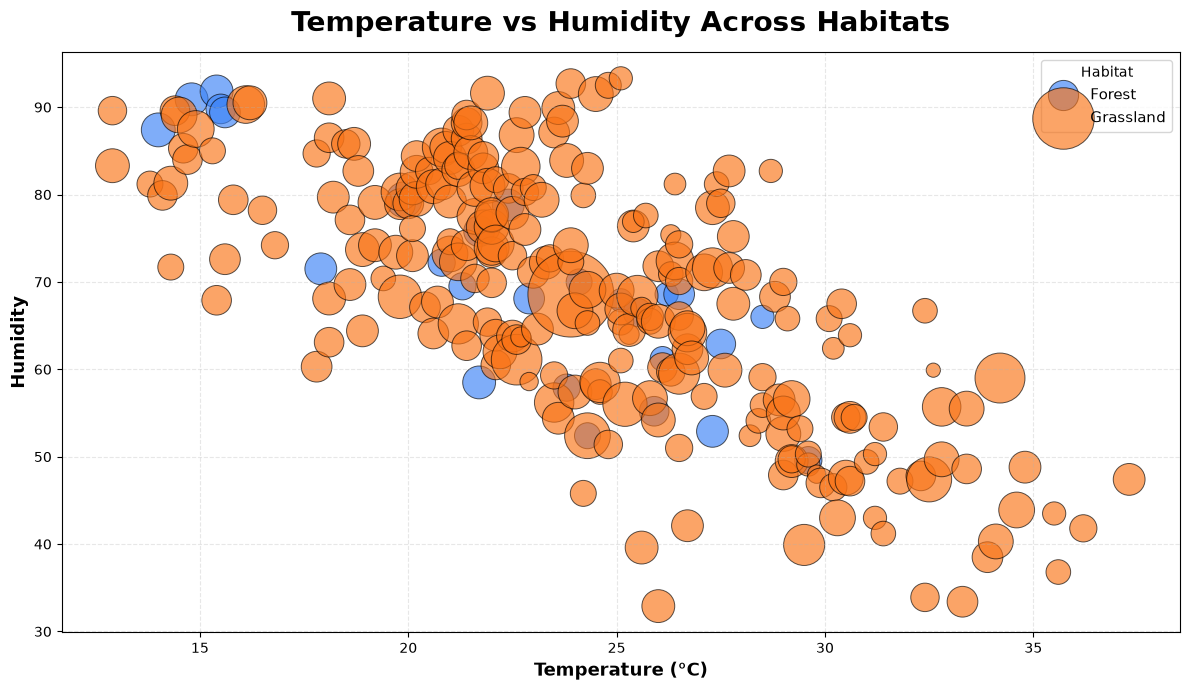

In [22]:
# ============================================================
# MULTIVARIATE CHART 1
# Temperature vs Humidity by Habitat
# Bubble Size = Number of Observations
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Create grouped data
bubble_data = (
    df.dropna(subset=['Temperature', 'Humidity', 'Habitat'])
      .groupby(['Habitat', 'Temperature', 'Humidity'])
      .size()
      .reset_index(name='Observation_Count')
)

# Plot
plt.figure(figsize=(12, 7))

habitats = bubble_data['Habitat'].unique()

colors = ['#3B82F6', '#F97316', '#22C55E', '#A855F7']

for i, habitat in enumerate(habitats):
    temp = bubble_data[bubble_data['Habitat'] == habitat]

    plt.scatter(
        temp['Temperature'],
        temp['Humidity'],
        s=temp['Observation_Count'] * 35,
        alpha=0.65,
        color=colors[i % len(colors)],
        edgecolor='black',
        linewidth=0.7,
        label=habitat
    )

# Titles and labels
plt.title(
    'Temperature vs Humidity Across Habitats',
    fontsize=20,
    fontweight='bold',
    pad=15
)

plt.xlabel('Temperature (°C)', fontsize=13, fontweight='bold')
plt.ylabel('Humidity', fontsize=13, fontweight='bold')

# Grid
plt.grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='Habitat',
    fontsize=11
)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- The chart shows an overall **negative relationship between Temperature and Humidity**, where humidity generally decreases as temperature increases.
- **Grassland accounts for a significantly higher number of observations** compared with Forest.
- The highest concentration of observations appears around **moderate temperatures and medium-to-high humidity levels**.
- Larger bubbles indicate environmental conditions where bird observations were recorded more frequently.

### 🎯 Business Recommendation

- Bird monitoring activities should be prioritized during **moderate-temperature and higher-humidity conditions** to maximize observation opportunities.
- **Grassland areas should receive higher monitoring priority** due to their substantially greater observation volume.
- Temperature and Humidity should be consistently recorded during future surveys to identify **environmental conditions associated with higher bird activity**.

# 📊 Multivariate Chart 2: Correlation Between Numerical Variables

### ❓ Business Question
What are the relationships between the key numerical variables in the bird observation dataset?

### 🎯 Objective
- Identify strong positive or negative relationships between numerical variables.
- Understand which environmental and observation variables move together.
- Identify variables that may be useful for further analysis or predictive modeling.

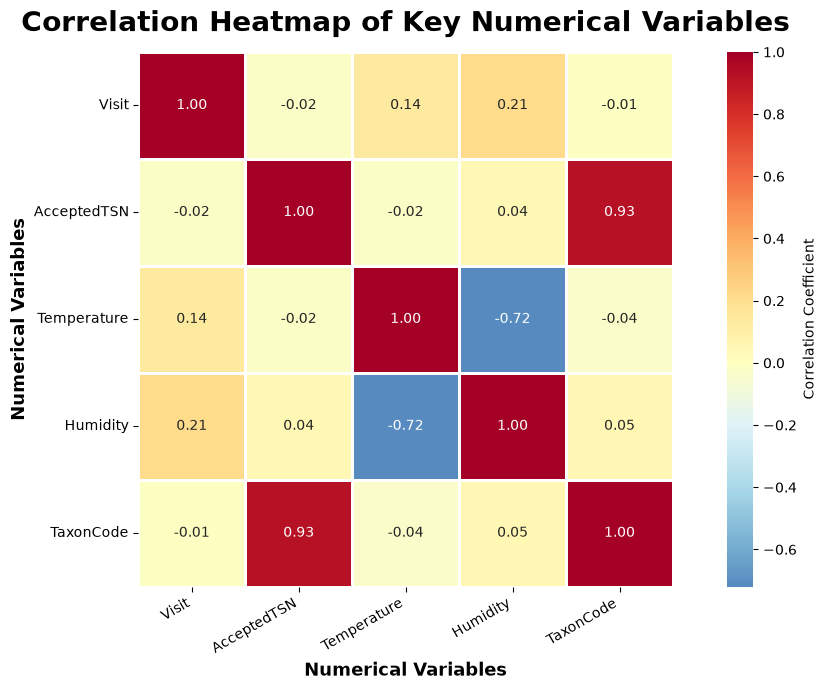

In [23]:
# ============================================================
# MULTIVARIATE CHART 2
# Correlation Heatmap of Numerical Variables
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select important numerical variables
corr_cols = [
    'Visit',
    'AcceptedTSN',
    'Temperature',
    'Humidity',
    'TaxonCode'
]

# Calculate correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(11, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=1,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    'Correlation Heatmap of Key Numerical Variables',
    fontsize=20,
    fontweight='bold',
    pad=15
)

plt.xlabel('Numerical Variables', fontsize=13, fontweight='bold')
plt.ylabel('Numerical Variables', fontsize=13, fontweight='bold')

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- The correlation heatmap provides an overview of how the key numerical variables are related to each other.
- Temperature and Humidity represent important environmental factors that can be analyzed together with bird observation-related variables.
- Visit, AcceptedTSN, and TaxonCode show different levels of association, helping identify variables that may contain overlapping or independent information.
- The heatmap can also help identify variables with stronger relationships that may be useful for further statistical analysis and predictive modeling.

### 🎯 Business Recommendation

- Environmental variables such as Temperature and Humidity should be consistently monitored during bird surveys.
- Highly correlated variables, if identified, should be evaluated carefully before using them together in predictive models to avoid redundant information.
- Visit-level and species-related variables should be retained for further analysis where they provide meaningful information about observation patterns.
- Correlation analysis should be combined with domain knowledge and additional statistical tests before making conservation or monitoring decisions.

# 🥧 Multivariate Chart 3: Habitat Share Across Survey Visits

### ❓ Business Question
How does the proportion of bird observations from each habitat change across survey visits?

### 🎯 Objective
- Compare the contribution of Forest and Grassland to total observations in each visit.
- Identify whether habitat representation changes across visits.
- Understand the relative share of each habitat rather than only absolute counts.

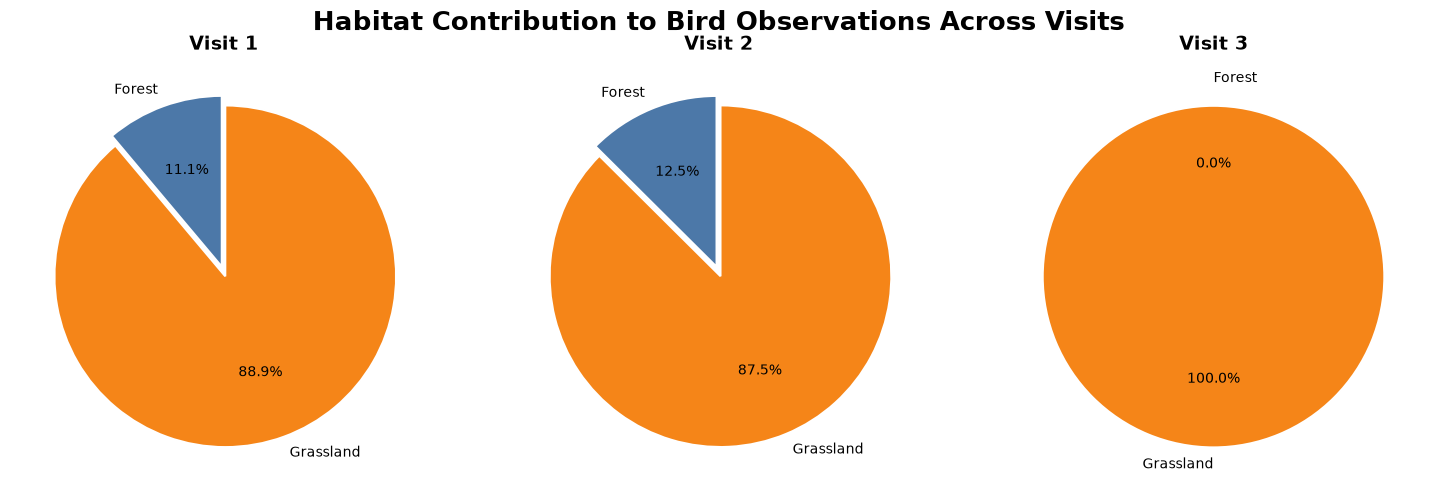

In [25]:
# ============================================================
# MULTIVARIATE CHART 3
# Habitat Share Across Visits - Pie Charts
# ============================================================

import matplotlib.pyplot as plt

# Count observations by Visit and Habitat
visit_habitat = pd.crosstab(
    df["Visit"],
    df["Habitat"]
)

# Create pie charts
fig, axes = plt.subplots(
    1,
    len(visit_habitat),
    figsize=(15, 5)
)

colors = ["#4C78A8", "#F58518"]

for ax, (visit, values) in zip(
    axes,
    visit_habitat.iterrows()
):

    ax.pie(
        values,
        labels=values.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=[0.03] * len(values),
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1.5
        }
    )

    ax.set_title(
        f"Visit {visit}",
        fontsize=14,
        fontweight="bold"
    )

fig.suptitle(
    "Habitat Contribution to Bird Observations Across Visits",
    fontsize=19,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- The pie charts show the relative contribution of Forest and Grassland observations within each survey visit.
- Grassland represents the dominant share of observations across the survey visits.
- The habitat proportions can be compared across visits to identify changes in sampling representation.

### 🎯 Business Recommendation

- Maintain consistent habitat coverage across future visits to improve comparability.
- Continue monitoring Grassland because it contributes the majority of observations.
- Ensure Forest sites are consistently surveyed to avoid under-representation in the dataset.

# 📊 Multivariate Chart 4: Species Observations Across Habitats and Visits

### ❓ Business Question
How does the observation frequency of major bird species change across habitats and visits?

### 🎯 Objective
- Compare species-level observation patterns across habitats.
- Analyze variation in observations across different visits.
- Identify species with consistent or changing observation patterns.

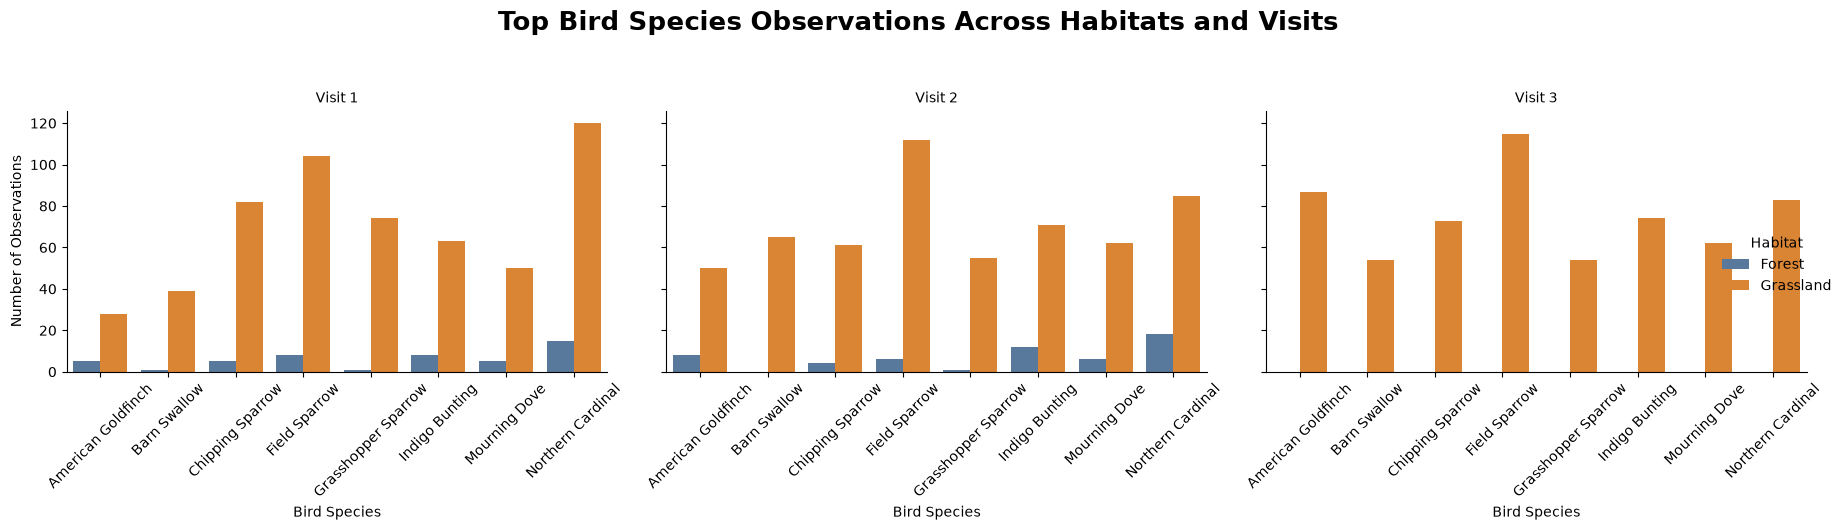

In [26]:
# ============================================================
# MULTIVARIATE CHART 4
# Species × Habitat × Visit
# ============================================================

top_species = (
    df['Common_Name']
    .value_counts()
    .head(8)
    .index
)

species_data = df[df['Common_Name'].isin(top_species)].copy()

species_visit = (
    species_data
    .groupby(['Common_Name', 'Visit', 'Habitat'])
    .size()
    .reset_index(name='Observation_Count')
)

g = sns.catplot(
    data=species_visit,
    x='Common_Name',
    y='Observation_Count',
    hue='Habitat',
    col='Visit',
    kind='bar',
    palette=['#4C78A8', '#F58518'],
    height=5,
    aspect=1.15
)

g.set_axis_labels('Bird Species', 'Number of Observations')
g.set_titles('Visit {col_name}')

g.fig.suptitle(
    'Top Bird Species Observations Across Habitats and Visits',
    fontsize=19,
    fontweight='bold',
    y=1.05
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Observation patterns differ across species, habitats, and visits.
- Some species show stronger representation in Grassland, while others have relatively higher observations in Forest.
- Variation across visits indicates that species activity is not uniform throughout the survey period.

### 🎯 Business Recommendation

- Monitoring plans should consider species-specific habitat preferences rather than applying the same strategy to all species.
- Species showing low or declining observations across visits should receive additional monitoring attention.
- Habitat-specific conservation strategies can be developed for species showing strong habitat associations.

# 📊 Multivariate Chart 5: Environmental Conditions and Bird Activity

### ❓ Business Question
How do temperature, humidity, and bird activity interact across different habitats?

### 🎯 Objective
- Examine bird activity under different temperature and humidity conditions.
- Compare environmental patterns between habitats.
- Identify environmental conditions associated with higher bird activity.

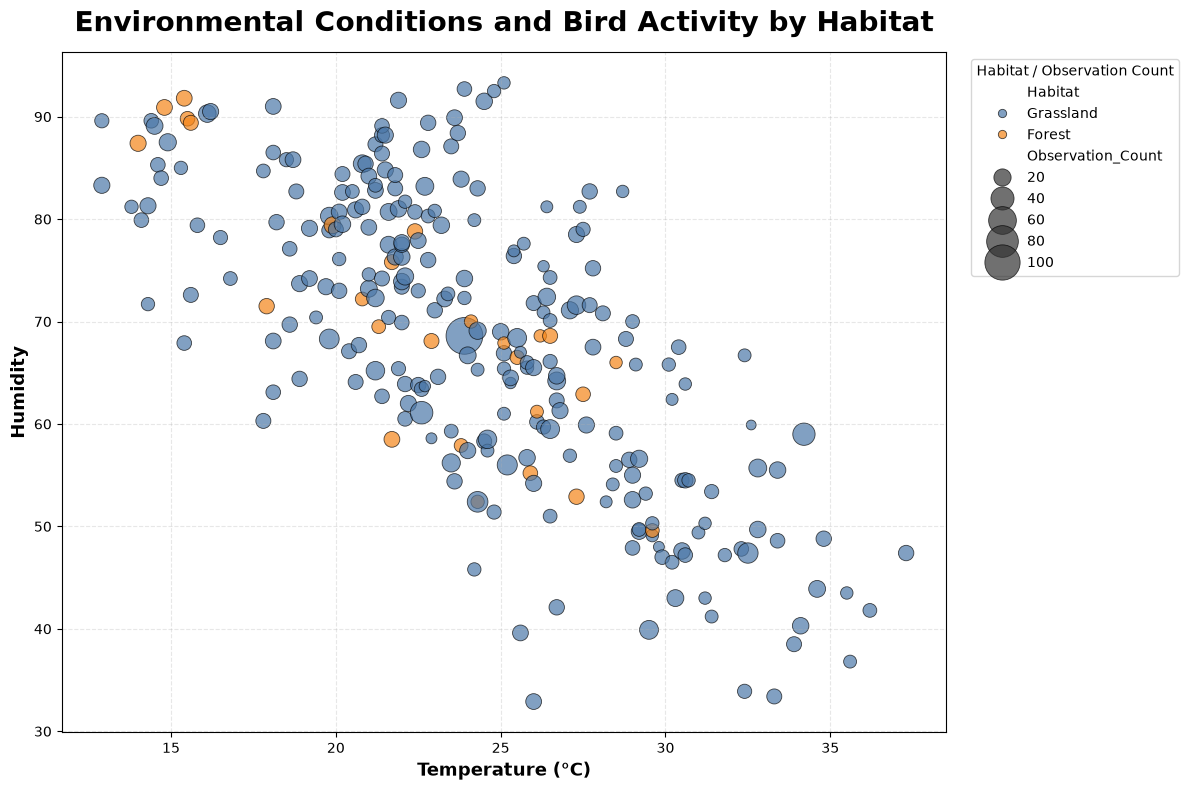

In [27]:
# ============================================================
# MULTIVARIATE CHART 5
# Temperature × Humidity × Bird Activity × Habitat
# ============================================================

env_data = (
    df.dropna(subset=['Temperature', 'Humidity', 'Habitat'])
      .groupby(['Temperature', 'Humidity', 'Habitat'])
      .size()
      .reset_index(name='Observation_Count')
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=env_data,
    x='Temperature',
    y='Humidity',
    size='Observation_Count',
    hue='Habitat',
    sizes=(50, 700),
    alpha=0.7,
    palette=['#4C78A8', '#F58518'],
    edgecolor='black',
    linewidth=0.6
)

plt.title(
    'Environmental Conditions and Bird Activity by Habitat',
    fontsize=20,
    fontweight='bold',
    pad=15
)

plt.xlabel('Temperature (°C)', fontsize=13, fontweight='bold')
plt.ylabel('Humidity', fontsize=13, fontweight='bold')

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='Habitat / Observation Count',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Bird activity varies across different combinations of temperature and humidity.
- Grassland shows a broader and more concentrated range of observations compared with Forest.
- The size of the bubbles highlights environmental conditions where observations occur more frequently.
- This suggests that environmental conditions can be useful for understanding variation in bird activity.

### 🎯 Business Recommendation

- Future bird surveys should record temperature and humidity consistently to support environmental analysis.
- Monitoring can be prioritized around environmental conditions associated with higher observation frequency.
- Combining habitat and environmental information can improve the planning and efficiency of future bird monitoring programs.